19 · Reproducible pipelines

A published figure needs a record of what was run, with which parameters and
which seed, repeatable by somebody else. A JSON or YAML specification
describes the whole pipeline (data, analysis, layout, style, render, exports);
the executor replays it step by step and writes a provenance manifest with
hashes.

## 0 · Setup

In [1]:
import json
import pathlib
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

# The executor sets `use_cache` but not `cache_folder`, leaving it relative to
# Blender's cwd, so an identical spec re-downloads when replayed from anywhere
# else. Point it at `notebooks/data/` before the pipeline fetches anything.
nb.osmnx()

# Not re-exported by the package; these have to come from the module directly.
from SciGraphs.core.repro.executor import run_pipeline
from scigraphs_core.repro.parser import parse_pipeline

PIPELINES = nb.repo("examples", "pipelines")
OUTPUT_DIR = nb.out("07_repro")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("example specifications:", PIPELINES)

scigraphs-utils available - Graphviz layouts enabled
example specifications: examples/pipelines


## 1 · What is already written

In [2]:
specs = sorted(p for p in PIPELINES.glob("*.json"))
print(f"{len(specs)} specifications:\n")
for path in specs:
    try:
        spec = json.loads(path.read_text(encoding="utf-8"))
    except json.JSONDecodeError:
        continue
    meta = spec.get("meta", {})
    source = spec.get("dataset", {}).get("source", "?")
    print(f"  {path.name:<42} {source:<12} {meta.get('title', '')}")

23 specifications:

  01_scigraphs_full.json                     osmnx        scigraphs_full_pipeline
  02_osmnx_network.json                      osmnx        osmnx_street_network_analysis
  03_city2graph_morphology.json              city2graph   city2graph_morphology
  04_city2graph_proximity.json               city2graph   city2graph_proximity
  05_city2graph_metapaths.json               osmnx        city2graph_metapaths
  06_suitesparse.json                        suitesparse  suitesparse_spectral
  07_sql.json                                sql          sql_database_graph
  08_topology.json                           gexf         topology_analysis
  09_render_eevee.json                       gexf         render_eevee_presentation
  10_ops_only_advanced.json                  ?            ops_only_advanced
  burjassot_bike_orientation_repro.json      osmnx        burjassot_bike_orientation_repro
  burjassot_drive_travel_time_repro.json     osmnx        burjassot_drive_travel_time_rep

In [3]:
for name in ("03_city2graph_morphology.json",
             "04_city2graph_proximity.json",
             "05_city2graph_metapaths.json"):
    path = PIPELINES / name
    if not path.exists():
        continue
    spec = json.loads(path.read_text(encoding="utf-8"))
    print(f"\n--- {name}")
    print(f"    {spec['meta'].get('description', '')}")
    for op in spec.get("ops", []):
        print(f"    op  {op['id']}")
        for group, props in op.get("scene_props", {}).items():
            for key, value in props.items():
                print(f"          scene.{group}.{key} = {value!r}")


--- 03_city2graph_morphology.json
    Download Overture data by place, generate tessellation and a morphological graph using nested city2graph scene_props.
    op  scigraphs.c2g_generate_tessellation
          scene.city2graph.c2g_tessellation_shrink = 0.4
          scene.city2graph.c2g_tessellation_segment = 0.5
    op  scigraphs.c2g_morphological_graph
          scene.city2graph.morpho_use_center_from_osmnx = True
          scene.city2graph.morpho_distance = 1000.0
          scene.city2graph.morpho_clipping_buffer = 50.0
          scene.city2graph.morpho_contiguity = 'queen'
          scene.city2graph.morpho_keep_buildings = True
          scene.city2graph.morpho_keep_segments = True

--- 04_city2graph_proximity.json
    Build a KNN proximity graph from a feature layer and color it, driving city2graph and coloring groups via nested scene_props.
    op  scigraphs.generate_proximity_graph
          scene.city2graph.prox_graph_type = 'KNN'
          scene.city2graph.prox_knn_k = 8
    

## 2 · Anatomy of a specification

Eight sections, all optional except `meta`:

| Section | What it controls |
|---|---|
| `meta` | title, seed, output directory, description |
| `dataset` | source (`osmnx`, `city2graph`, file, SQL, SuiteSparse) |
| `ops` | operators in order, with the scene properties each one needs |
| `analysis` | centralities, clustering, statistics |
| `layout` | algorithm and its parameters |
| `visual` | Geometry Nodes, colormap, edge style |
| `render` | engine, camera, resolution |
| `exports` | graph, positions, statistics |

`meta.seed` makes force layouts, sampling and Waxman deterministic.

In [4]:
spec_prox = json.loads((PIPELINES / "04_city2graph_proximity.json").read_text())
print(json.dumps(spec_prox, indent=2, ensure_ascii=False))

{
  "meta": {
    "title": "city2graph_proximity",
    "seed": 123,
    "output_dir": "//repro/04_city2graph_proximity",
    "description": "Build a KNN proximity graph from a feature layer and color it, driving city2graph and coloring groups via nested scene_props."
  },
  "dataset": {
    "source": "city2graph",
    "bbox": [
      -0.43,
      39.5,
      -0.4,
      39.52
    ]
  },
  "ops": [
    {
      "id": "scigraphs.generate_proximity_graph",
      "scene_props": {
        "city2graph": {
          "prox_graph_type": "KNN",
          "prox_knn_k": 8,
          "prox_distance_metric": "EUCLIDEAN",
          "prox_curve_thickness": 0.02,
          "prox_visualize_limit": 20000
        }
      }
    },
    {
      "id": "scigraphs.color_apply",
      "scene_props": {
        "coloring": {
          "colormap": "plasma",
          "auto_range": true
        }
      }
    }
  ],
  "visual": {
    "setup_geometry_nodes": true,
    "node_max_size": 0.12
  },
  "exports": {
    "grap

## 3 · The hash of a specification

`parse_pipeline()` validates, canonicalizes (sorted keys, normalized values)
and returns the hash that goes into the manifest. Two specifications that say
the same thing hash the same; changing one parameter changes it.

In [5]:
schema, raw, hash_spec = parse_pipeline(str(PIPELINES / "04_city2graph_proximity.json"))
print("hash:", hash_spec)
print("title:", schema.meta.title)
print("seed:", schema.meta.seed)

reordered = {k: spec_prox[k] for k in reversed(list(spec_prox.keys()))}
_, _, hash_reordered = parse_pipeline(reordered)
check("the hash is independent of the key order",
      hash_spec == hash_reordered, f"{hash_spec[:12]} vs {hash_reordered[:12]}")

modified = json.loads(json.dumps(spec_prox))
modified["ops"][0]["scene_props"]["city2graph"]["prox_knn_k"] = 12
_, _, hash_modified = parse_pipeline(modified)
check("the hash changes if a parameter changes", hash_spec != hash_modified,
      f"k=8 -> {hash_spec[:12]}, k=12 -> {hash_modified[:12]}")

hash: ebea92d5df0a65e04aa6aa217107fb7b0136547cccb0cc325b232e5c950e2cfe
title: city2graph_proximity
seed: 123
[PASS] the hash is independent of the key order — ebea92d5df0a vs ebea92d5df0a
[PASS] the hash changes if a parameter changes — k=8 -> ebea92d5df0a, k=12 -> 9cf3a75348ec


True

## 4 · Writing a specification from the notebook

You explored in notebook 16, a kNN with k=6 over the restaurants of a
neighborhood convinced you, now freeze it.

In [6]:
my_spec = {
    "meta": {
        "title": "proximity_valencia_knn6",
        "seed": 42,
        "output_dir": str(OUTPUT_DIR / "run"),
        "description": "kNN k=6 over the amenities of Ciutat Vella, colored by degree.",
    },
    "dataset": {
        "source": "osmnx",
        "method": "PLACE",
        "query": "Burjassot, Valencia, Spain",
        "network_type": "walk",
        "simplify": True,
    },
    "ops": [
        {"id": "scigraphs.osmnx_project_graph"},
        {
            "id": "scigraphs.calculate_centrality",
            "scene_props": {"scigraphs": {"centrality_type": "BETWEENNESS"}},
        },
    ],
    "visual": {
        "setup_geometry_nodes": True,
        # This spec is the notebook's own example file, so it tracks the house
        # style; otherwise the figure would contradict the file it renders.
        "colormap": "turbo",
        "edge_style": "CYTOSCAPE_BEZIER",
    },
    "exports": {
        "graph": "network.graphml",
        "positions": "positions.csv",
        "statistics": "statistics.txt",
    },
}

spec_path = OUTPUT_DIR / "my_pipeline.json"
spec_path.write_text(json.dumps(my_spec, indent=2, ensure_ascii=False), encoding="utf-8")
print("written:", nb.rel(spec_path))

written: notebooks/out/07_repro/my_pipeline.json


In [7]:
try:
    my_schema, _, my_hash = parse_pipeline(str(spec_path))
    print("valid. hash:", my_hash)
    print("operators:", [op.id for op in (my_schema.ops or [])])
    check("the specification is valid", True)
except Exception as exc:
    print("rejected:", type(exc).__name__, exc)
    check("the specification is valid", False, str(exc))

valid. hash: aa4db7a3780070d8a2e83b2ab3bfc9abf79a404122233a6a2bb7ab2bc1fca3a2
operators: ['scigraphs.osmnx_project_graph', 'scigraphs.calculate_centrality']
[PASS] the specification is valid


### Careful: fields that do not exist are dropped silently

`parse_pipeline()` validates types and values but does **not** reject unknown
keys: `_dataclass_kwargs()` filters the dictionary down to the fields the
dataclass declares and drops the rest silently. Same pattern notebooks 13 to
05 document: the call does not fail, it does something else.

This notebook was first written with
`"method": "POINT", "latitude": …, "longitude": …, "distance": …`; it validated
without a complaint and downloaded **Madrid** with a radius of 1000 m, because
`DatasetSpec` has none of those three fields and the executor fell back to the
scene defaults. So contrast the keys written against the declared fields.

In [8]:
import dataclasses

from scigraphs_core.repro.schema import DatasetSpec

declared = {f.name for f in dataclasses.fields(DatasetSpec)}
written = set(my_spec["dataset"])
dropped = written - declared

print("DatasetSpec fields   :", ", ".join(sorted(declared)))
print("written by us        :", ", ".join(sorted(written)))
check("no dataset field is dropped", not dropped,
      ", ".join(sorted(dropped)) if dropped else "")

bad = {"source": "osmnx", "method": "POINT",
       "latitude": 39.4699, "longitude": -0.3763, "distance": 600}
print("\ndropped from the POINT version:",
      ", ".join(sorted(set(bad) - declared)))

DatasetSpec fields   : auto_layout, bbox, cache, connection_string, edges_query, filepath, giant_only, layers, matrix_mode, matrix_name, method, network_type, nodes_query, query, retain_all, simplify, source
written by us        : method, network_type, query, simplify, source
[PASS] no dataset field is dropped

dropped from the POINT version: distance, latitude, longitude


To locate an area the schema offers `query` (with
`method: "PLACE"`, as above) or `bbox`. There is no point + radius.

The validator is also an operator, the one the Reproducibility panel uses. As
an `ImportHelper` it opens a file browser when called without arguments; from
a notebook, pass `filepath=` explicitly.

In [9]:
repro = bpy.context.scene.scigraphs_repro
repro.pipeline_path = str(spec_path)          # what the panel reads
repro.artifacts_path = str(OUTPUT_DIR) + "/"

print("validate_pipeline ->", bpy.ops.scigraphs.validate_pipeline(filepath=str(spec_path)))

Info: Pipeline is valid! Hash: aa4db7a3780070d8...
validate_pipeline -> {'FINISHED'}


## 5 · Running it

`stop_on_error=False` carries on after a failure and notes it down, for
unattended batches; `True` stops at the first problem, better while debugging.

It needs internet: the specification downloads the network from OSMnx.

In [10]:
import time

t0 = time.time()
result = run_pipeline(str(spec_path), stop_on_error=False, verbose=True)
print(f"\n{time.time() - t0:.0f} s")

print(f"success     : {result.success}")
print(f"hash        : {result.pipeline_hash}")
print(f"output      : {nb.rel(result.output_dir)}")
print(f"manifest    : {nb.rel(result.manifest_path) if result.manifest_path else None}")
print(f"artifacts   : {len(result.artifacts)}")
for artifact in result.artifacts:
    print("   ", artifact)
if result.errors:
    print("errors:")
    for error in result.errors:
        print("   ", error.strip().splitlines()[-1])

[SciGraphs Repro] Executing pipeline: proximity_valencia_knn6
[SciGraphs Repro] Output directory: notebooks/out/07_repro/run
[SciGraphs Repro] Pipeline hash: aa4db7a3780070d8...
[SciGraphs Repro] Set global seed: 42
[SciGraphs Repro] Cleared scene: 3 object(s) removed
[SciGraphs Repro] Loading dataset: osmnx

  Place: Burjassot, Valencia, Spain
  Download completed in 1.78s
Total import time: 2.18s
  Nodes: 2,302, Edges: 6,980

Creating OSMnx graph: 2,302 nodes, 6,980 edges...
  Created 2,302 intersection vertices
    Created 1,000 edges...
    Created 2,000 edges...
    Created 3,000 edges...
  Created 3,440 street edges in 0.68s
Total OSMnx graph creation time: 0.68s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/Burjassot_Valencia_Spain_walk.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/Burjassot_Valencia_Spain_walk.graphml
Info: Downloading network from OpenStreetMap (PLACE)...
Info: Graph cached as: Burjassot_Valenci

## 6 · The provenance manifest

Versions, input and output hashes, duration per step, effective seed.

In [11]:
if result.manifest_path and pathlib.Path(result.manifest_path).exists():
    manifest = json.loads(pathlib.Path(result.manifest_path).read_text())
    print("keys:", list(manifest.keys()))
    for key in ("pipeline_hash", "started_at", "duration_ms", "seed"):
        if key in manifest:
            print(f"  {key:<16} {manifest[key]}")
    steps = manifest.get("steps", [])
    print(f"\n{len(steps)} steps recorded:")
    for step in steps[:12]:
        print(f"  {step.get('name', '?'):<40} "
              f"{step.get('duration_ms', 0):>7} ms  {step.get('status', '')}")
    outputs = manifest.get("outputs", [])
    if outputs:
        print(f"\n{len(outputs)} outputs with a hash:")
        for output in outputs[:8]:
            print(f"  {output.get('path', '?'):<44} "
                  f"{str(output.get('hash', ''))[:16]}")
    check("the manifest records the steps", len(steps) > 0)
else:
    print("no manifest: the run did not get to finish")

keys: ['pipeline_hash', 'pipeline_title', 'seed', 'environment', 'dependencies', 'inputs', 'outputs', 'steps', 'started_at', 'completed_at', 'duration_ms', 'success', 'warnings', 'notes', 'output_dir']
  pipeline_hash    aa4db7a3780070d8a2e83b2ab3bfc9abf79a404122233a6a2bb7ab2bc1fca3a2
  started_at       2026-08-18T08:37:43.423561+00:00
  duration_ms      6464
  seed             42

5 steps recorded:
  dataset                                     3229 ms  success
  visual                                         8 ms  success
  op_0                                         171 ms  success
  op_1                                          17 ms  success
  exports                                     2796 ms  success

2 outputs with a hash:
  notebooks/out/07_repro/run/network.graphml b44e27787fbc7f70
  notebooks/out/07_repro/run/statistics.txt 6ef33db922def6e7
[PASS] the manifest records the steps


## Rendering

Rendered with EEVEE through `nb.figure()` (notebook 13).

No terrain, buildings or aerial imagery: the specification decides what
arrives, and a failed download leaves nothing. Guessing a center and radius
for an unknown graph puts the network over the wrong kilometer; guessing a
tile zoom fetches several hundred tiles. Call `sg.context.add_context()`
once you know what the specification builds.

Style as in notebooks 00 to 07, from notebook 15: `look='ink'`, straight down
through an orthographic camera, top percentile clipped because street
centrality is long-tailed and a few through-routes would take the whole ramp.

Colormap and color attribute are read out of the specification rather than
named here, so the figure cannot contradict the file it renders.
`scigraphs.calculate_centrality` writes `centrality_<method>` on the POINT
domain, the method set by the operator's default and by what `scene_props`
managed to apply; with nothing computed the graph renders neutral.

> On Blender's **Vulkan** backend (the default on Linux)
> `gpu.state.point_size_set` does nothing for the add-on shaders, so `POINT`
> and `DISK` nodes come out **1 pixel** wide in the SciGraphs engine, which
> notebook 05 still uses for the preview controls; notebook 06 does not, since
> `SciGraphs.api.thin` moved the edge sparsification into the mesh where EEVEE can see
> it. Start Blender with `--gpu-backend opengl` for any render you intend to
> look at.

### The state of the scene depends on the specification

`meta.clear_scene` is `True` by default, so **every** run empties the scene
first. Two `run_pipeline()` calls do not accumulate: the second erases what
the first left, and if its data stage fails what remains is an empty scene.
Render what a pipeline produces right after that run.

1 graph(s) left behind by the run in section 5
  OSMnx_StreetNetwork              2,302 nodes
OSMnx_StreetNetwork: coloring by centrality_degree
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> centrality_degree  ·  centrality_degree -> turbo [rank]  [0 … 0.001738] on Point


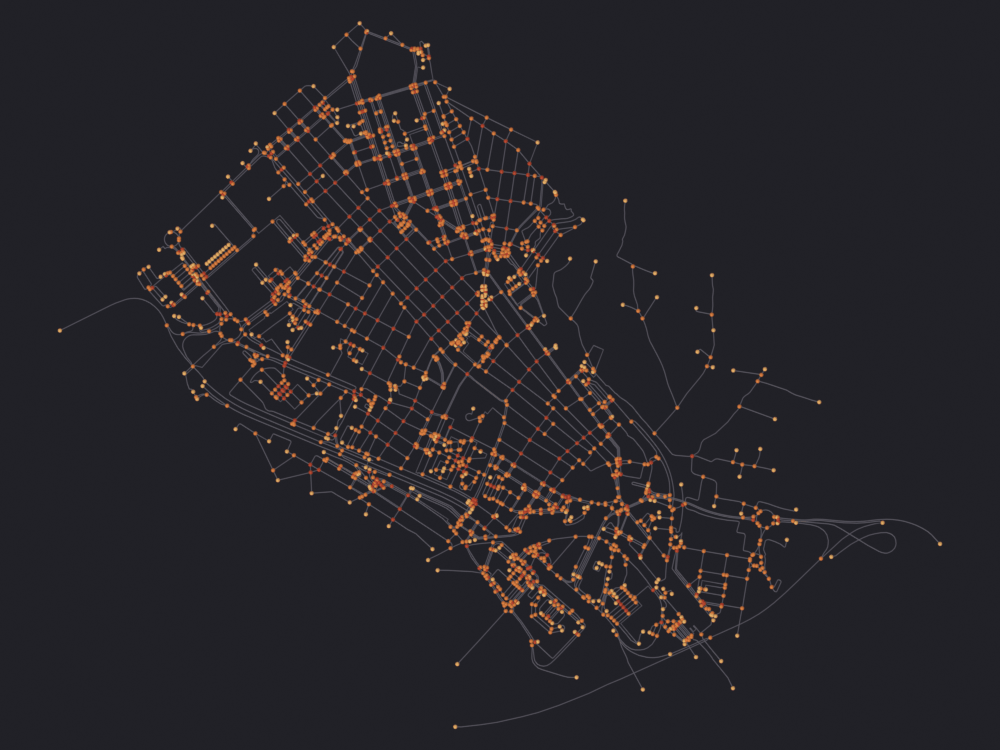

[PASS] OSMnx_StreetNetwork.png legible — 9.8% ink (healthy range 0.5–60%)
[PASS] the pipeline left a renderable graph


In [12]:
graphs = {o.name: o for o in bpy.data.objects if "num_nodes" in o.keys()}
print(f"{len(graphs)} graph(s) left behind by the run in section 5")
for name, obj in graphs.items():
    print(f"  {name:<30} {obj.get('num_nodes'):>7,} nodes")

def computed_attribute(obj):
    """The scalar the pipeline's analysis step left behind, or None.

    `calculate_centrality` names its output after the method it ran, so the
    attribute is `centrality_degree`, `centrality_betweenness`, and so on. The
    notebook cannot know which without reading the mesh back: the specification
    decides.
    """
    for name, domain, _dtype in sg.graphs.attributes(obj):
        if name.startswith("centrality_") and domain == 'POINT':
            return name
    return None


if graphs:
    for name, obj in list(graphs.items())[:2]:
        attribute = computed_attribute(obj)
        print(f"{name}: coloring by "
              f"{attribute or '(nothing: the run computed no centrality)'}")
        # An OSMnx import puts a vertex at every geometry point, so the median
        # nearest-neighbor distance the 0.35 default scales is a few meters and
        # draws a sphere under a pixel. Colormap-colored pixels at 1000x750:
        # 1.1 % at 0.35, 3.5 % at 0.9, 7.5 % at 1.6. By 1.6 the spheres have
        # swallowed the streets; 0.9 still reads as a network.
        nb.figure(obj, f"renders/19_repro/{name}",
                  look='ink',
                  colormap=my_spec["visual"]["colormap"],
                  color_attribute=attribute, clip_high_pct=98,
                  node_fraction=0.9)
else:
    print("The pipeline left no graph. It is usually the download:")
    for error in result.errors[:3]:
        print("   ", error.strip().splitlines()[-1])

# A rate-limited Overpass leaves nothing to render, which is not an engine
# failure and must not be checked as one.
if result.success:
    check("the pipeline left a renderable graph", bool(graphs))
else:
    print("\nThe run in section 5 failed, so there is nothing to render. "
          "Try again in a little while.")

## 7 · Running it again and comparing

Two runs of the same specification must give the same hash and the same
outputs.

In [13]:
result_2 = run_pipeline(str(spec_path), stop_on_error=False, verbose=False)
check("the hash is stable across runs",
      result.pipeline_hash == result_2.pipeline_hash,
      result.pipeline_hash)

positions = pathlib.Path(result.output_dir) / "positions.csv"
if positions.exists():
    import hashlib
    digest = hashlib.sha256(positions.read_bytes()).hexdigest()
    print("sha256 of positions.csv:", digest[:32])


  Place: Burjassot, Valencia, Spain
  Download completed in 1.83s
Total import time: 2.24s
  Nodes: 2,302, Edges: 6,980

Creating OSMnx graph: 2,302 nodes, 6,980 edges...
  Created 2,302 intersection vertices
    Created 1,000 edges...
    Created 2,000 edges...
    Created 3,000 edges...
  Created 3,440 street edges in 0.70s
Total OSMnx graph creation time: 0.70s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/Burjassot_Valencia_Spain_walk.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/Burjassot_Valencia_Spain_walk.graphml
Info: Downloading network from OpenStreetMap (PLACE)...
Info: Graph cached as: Burjassot_Valencia_Spain_walk.graphml
Info: Imported: 2302 intersections, 6980 street segments, 291.1 km total
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Applied edge style preset: CYTOSCAPE_BEZIER
OSMnx graph detected - preserving original street geometry

Diffs between two runs:

```bash
python3 scripts/repro/compare_runs.py <dir_a> <dir_b>
```

## 8 · Serializing the current scene

The reverse route: this operator writes the specification that reproduces what
you reached through the panel or earlier notebooks. It needs an active graph
object, found by looking for `num_nodes` in it.

In [14]:
destination = OUTPUT_DIR / "current_scene.json"
# Delete before writing, or a failed operator leaves the cell below reading the
# previous run's file. That is how this notebook once reported 2302 nodes with
# an empty scene.
destination.unlink(missing_ok=True)

graph = next((o for o in bpy.data.objects if "num_nodes" in o.keys()), None)

if graph is None:
    print("There is no graph in the scene; run notebook 13 or 04 first, "
          "or let cell 5 finish its download.")
else:
    sg.graphs.activate(graph)
    print("active object:", graph.name, f"({graph['num_nodes']} nodes)")
    print("export_current_repro_spec ->",
          bpy.ops.scigraphs.export_current_repro_spec(
          filepath=str(destination), format='JSON'))

if destination.exists():
    serialized = json.loads(destination.read_text(encoding="utf-8"))
    print("sections:", list(serialized.keys()))
    print(json.dumps(serialized.get("meta", {}), indent=2, ensure_ascii=False))
else:
    print("nothing written: the operator needs a scene with a graph loaded")

active object: OSMnx_StreetNetwork (2302 nodes)
Info: Pipeline spec exported to: notebooks/out/07_repro/current_scene.json
export_current_repro_spec -> {'FINISHED'}
sections: ['meta', 'dataset', 'visual', 'render']
{
  "title": "scene_OSMnx_StreetNetwork",
  "seed": 42,
  "output_dir": "//repro/exported",
  "description": "Exported from scene with 2302 nodes"
}


## 9 · In batches, from the terminal

One Blender process per specification isolates the failures:

```bash
env -u LD_LIBRARY_PATH blender -b --python scripts/repro/_run_one.py -- \
    --spec examples/pipelines/04_city2graph_proximity.json \
    --report /tmp/result.json
```

`env -u LD_LIBRARY_PATH` is not optional on this machine: the OpenFOAM
environment puts the system TBB ahead of the one Blender ships and startup
dies with an undefined symbol error.

A local model can draft the specification from a sentence, through Ollama, so
nothing leaves the machine. From a terminal:

```bash
python3 scripts/repro/ask.py "the pedestrian network of Burjassot colored by betweenness" --run
```

Notebook 20 does the same from here, and shows what happens between the
model's answer and the render: what gets stripped, what gets corrected, and
one request it refuses to run.

## 10 · The options reference

Autogenerated from the schema, so it does not fall behind:

- `docs/reference/pipeline-options.qmd`: options reference
- `docs/reference/pipeline.schema.json`: JSON schema, useful for autocompletion
- `docs/guide/pipeline-schema.qmd`: authoring guide

In [15]:
schema_path = nb.repo("docs", "reference", "pipeline.schema.json")
if schema_path.exists():
    data = json.loads(schema_path.read_text(encoding="utf-8"))
    print("schema sections:", list(data.get("properties", {}).keys()))
else:
    print("schema not found at", nb.rel(schema_path))

schema sections: ['meta', 'dataset', 'analysis', 'layout', 'visual', 'labels', 'world', 'lighting', 'render', 'exports', 'ops']
